# **LAB08 -  Koha e Reagimit: Te Dhena, Shperndarje dhe Probabilitet:**
---
- ##### Tema: **Koha e Reagimit: Te Dhena, Shperndarje dhe Probabilitet**
- ##### Studentja: Esma Tanushi
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 19.05.2026
---

## **Qellimi:**

Qellimi i ketij laboratori eshte te tregoje se koha e reagimit nuk eshte nje vlere e vetme, por nje shperndarje probabilitare.

Ne kete eksperiment studentet:
- mblodhen nje numer te madh matjesh,
- analizuan rezultatet statistikisht,
- ndertuan histogramet,
- dhe krahasuan rezultatet me nje model Gaussian.

Rezultatet tregojne se matjet eksperimentale kane variacion dhe pershkruhen me mire nga nje shperndarje sesa nga nje numer i vetem.

---

## **Teoria:**

Ne metoden e vizores, koha e reagimit llogaritet nga distanca e renies sipas formules:

$$
t = \sqrt{\frac{2d}{g}}
$$

ku:

- **( d )** eshte distanca e renies
- **( g = 9.81 , m/s^2 )**

Koha e reagimit ndryshon nga matja ne matje per shkak te:
- reagimit njerezor,
- perqendrimit,
- gabimeve eksperimentale,
- dhe faktoreve biologjike.

**Mesatarja:**

$$
\bar{t} = \frac{1}{N}\sum t_i
$$

**Devijimi standard:**

$$
\sigma = \sqrt{\frac{1}{N-1}\sum (t_i-\bar{t})^2}
$$

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

g = 9.81

---
# **PJESA A — MATJA ME VIZORE**

## Te Dhenat

In [14]:
import pandas as pd

artea_vizore = [
11,10,12,12,5,10,13,10,12,22,
5,13,13,7,14,5,10,7,5,12,
9,6,3,5,10,5,13,9,6,7
]

rei_vizore = [
17,15,30,21,18,14,40,12,18,17,
14,15,17,14,14,12,14,13,12,14,
10,14,11,12,12,15,12,30,9,12
]

esma_vizore = [
18,23,18,24,16,17,12,21,24,21,
29,22,25,10,20,17,11,16,19,6,
21,15,16,13,12,16,22,19,7,12
]

df_vizore = pd.DataFrame({
    "Artea": artea_vizore,
    "Rei": rei_vizore,
    "Esma": esma_vizore
})

df_vizore

,Artea,Rei,Esma
0,11,17,18
1,10,15,23
2,12,30,18
3,12,21,24
4,5,18,16
5,10,14,17
6,13,40,12
7,10,12,21
8,12,18,24
9,22,17,21


## **Llogaritja e Kohes se Reagimit:**

**Koha e reagimit u llogarit me formulen:**

$$
t = \sqrt{\frac{2d}{g}}
$$

### Artea =>

$$
t = \sqrt{\frac{2 \cdot 0.093}{9.81}} \approx 0.14s
$$

### Rei =>

$$
t = \sqrt{\frac{2 \cdot 0.157}{9.81}} \approx 0.18s
$$

### Esma =>

$$
t = \sqrt{\frac{2 \cdot 0.178}{9.81}} \approx 0.19s
$$

## **Rezultatet Mesatare:**

In [15]:
import numpy as np

g = 9.81

artea_vizore_t = [np.sqrt((2*d/100)/g) for d in artea_vizore]
rei_vizore_t = [np.sqrt((2*d/100)/g) for d in rei_vizore]
esma_vizore_t = [np.sqrt((2*d/100)/g) for d in esma_vizore]

mesataret = pd.DataFrame({
    "Studenti": ["Artea", "Rei", "Esma"],
    "Distanca mesatare (cm)": [
        np.mean(artea_vizore),
        np.mean(rei_vizore),
        np.mean(esma_vizore)
    ],
    "Koha mesatare (s)": [
        np.mean(artea_vizore_t),
        np.mean(rei_vizore_t),
        np.mean(esma_vizore_t)
    ]
})

mesataret

,Studenti,Distanca mesatare (cm),Koha mesatare (s)
0,Artea,9.366667,0.135191
1,Rei,15.933333,0.177388
2,Esma,17.400000,0.185838


## **Histogramet dhe Krahasimi me Shperndarjen Gaussiane:**

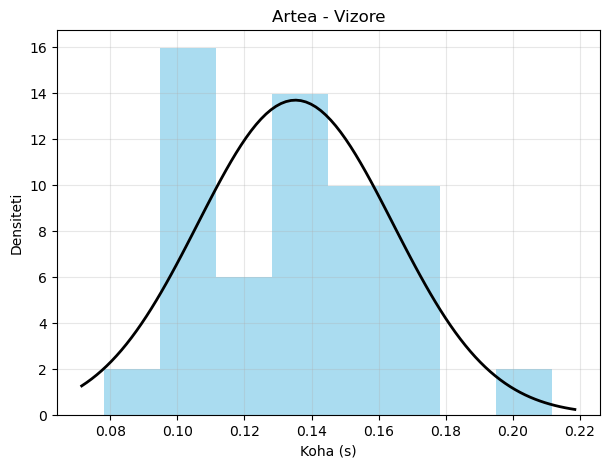

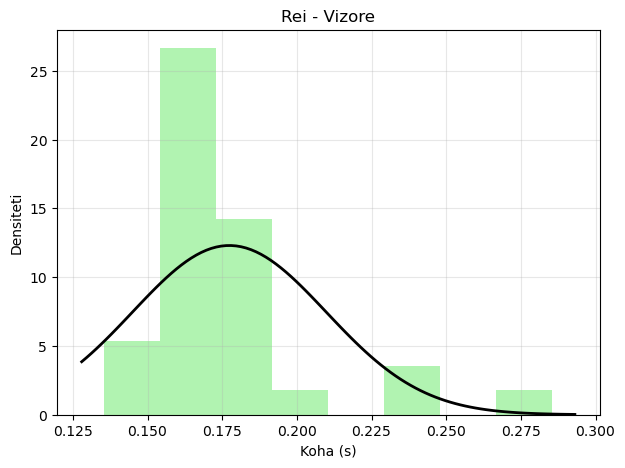

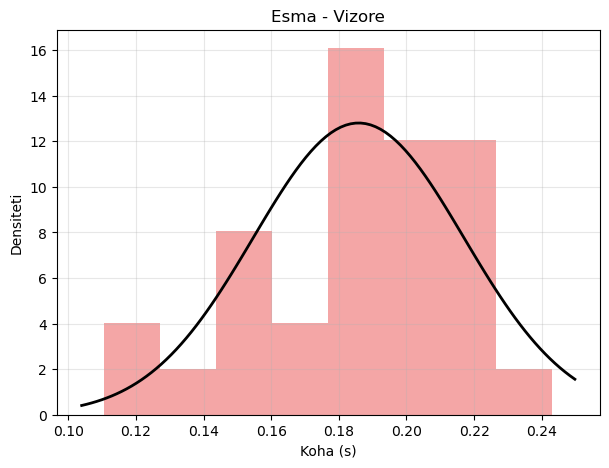

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def histogram(data, title, color):

    mean = np.mean(data)
    std = np.std(data, ddof=1)

    plt.figure(figsize=(7,5))

    plt.hist(
        data,
        bins=8,
        density=True,
        alpha=0.7,
        color=color
    )

    xmin, xmax = plt.xlim()

    x = np.linspace(xmin, xmax, 100)

    p = norm.pdf(x, mean, std)

    plt.plot(x, p, color="black", linewidth=2)

    plt.title(title)
    plt.xlabel("Koha (s)")
    plt.ylabel("Densiteti")

    plt.grid(alpha=0.3)

    plt.show()

histogram(artea_vizore_t, "Artea - Vizore", "skyblue")
histogram(rei_vizore_t, "Rei - Vizore", "lightgreen")
histogram(esma_vizore_t, "Esma - Vizore", "lightcoral")

---
# **PJESA B — KRONOMETRI 5 SEKONDA**

Ne kete pjese ne duhej te ndalonin kronometrin sa me afer vleres 5 sekonda.

## Te Dhenat:

In [17]:
artea_5s = [
5.061,5.035,5.018,5.045,4.990,
5.056,5.225,5.185,5.193,5.111
]

rei_5s = [
5.006,4.894,5.068,4.920,5.078,
4.958,4.866,5.049,4.909,4.962
]

esma_5s = [
5.069,4.884,4.989,5.161,4.400,
4.927,5.007,4.938,4.978,4.970
]

df_5s = pd.DataFrame({
    "Artea": artea_5s,
    "Rei": rei_5s,
    "Esma": esma_5s
})

df_5s

,Artea,Rei,Esma
0,5.061,5.006,5.069
1,5.035,4.894,4.884
2,5.018,5.068,4.989
3,5.045,4.920,5.161
4,4.990,5.078,4.400
5,5.056,4.958,4.927
6,5.225,4.866,5.007
7,5.185,5.049,4.938
8,5.193,4.909,4.978
9,5.111,4.962,4.970


## **Rezultatet Mesatare:**

In [18]:
mesataret_5s = pd.DataFrame({
    "Studenti": ["Artea", "Rei", "Esma"],
    "Koha mesatare (s)": [
        np.mean(artea_5s),
        np.mean(rei_5s),
        np.mean(esma_5s)
    ],
    "Devijimi standard": [
        np.std(artea_5s, ddof=1),
        np.std(rei_5s, ddof=1),
        np.std(esma_5s, ddof=1)
    ]
})

mesataret_5s

,Studenti,Koha mesatare (s),Devijimi standard
0,Artea,5.0919,0.081986
1,Rei,4.9710,0.075877
2,Esma,4.9323,0.202493


## **Histogramet dhe Krahasimi me Shperndarjen Gaussiane:**

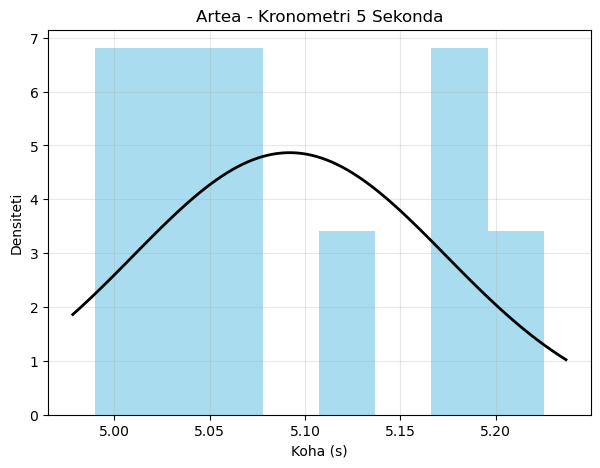

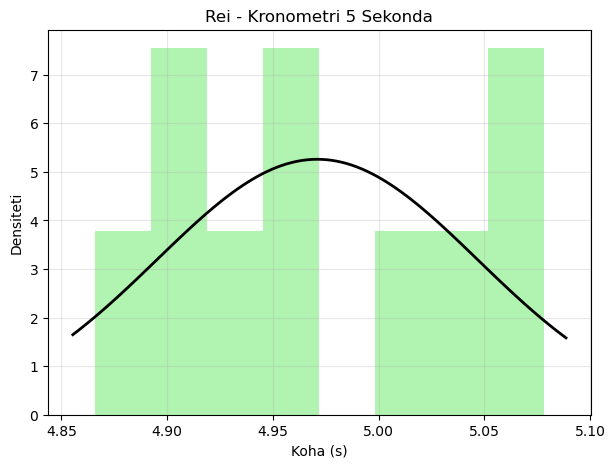

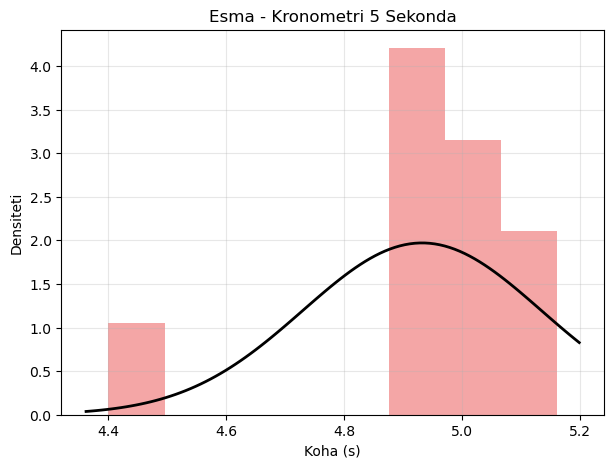

In [19]:
histogram(artea_5s, "Artea - Kronometri 5 Sekonda", "skyblue")
histogram(rei_5s, "Rei - Kronometri 5 Sekonda", "lightgreen")
histogram(esma_5s, "Esma - Kronometri 5 Sekonda", "lightcoral")

---
# **PJESA C — TESTI START/STOP:**

Ne kete pjese studentet ndiznin dhe ndalonin kronometrin sa me shpejt te ishte e mundur.

Rezultatet u regjistruan ne milisekonda dhe me pas u konvertuan ne sekonda.

## Te Dhenat:

In [20]:
artea_startstop = [
180,151,106,177,157,135,147,148,153,164,
151,160,154,256,172,223,197,146,154,156,
179,150,157,159,135,153,163,154,159,185,
129,172,183,207,162,163,184,198,176,175,
180,191,172,153,191,149,252,174,166,165
]

rei_startstop = [
194,156,150,149,152,151,159,145,149,134,
144,125,150,174,170,157,141,139,123,135,
132,125,137,136,126,122,148,138,137,126,
127,137,143,148,134,134,131,222,155,140,
132,139,137,170,136,136,146,143,136,121
]

esma_startstop = [
157,119,157,200,154,157,126,176,110,142,
161,178,161,162,161,194,174,182,159,126,
148,167,185,157,168,160,179,158,144,140,
142,134,193,179,206,171,169,195,163,151,
170,157,182,163,144,187,137,163,218,209
]

df_startstop = pd.DataFrame({
    "Artea": artea_startstop,
    "Rei": rei_startstop,
    "Esma": esma_startstop
})

df_startstop

,Artea,Rei,Esma
0,180,194,157
1,151,156,119
2,106,150,157
3,177,149,200
4,157,152,154
5,135,151,157
6,147,159,126
7,148,145,176
8,153,149,110
9,164,134,142


## **Konvertimi ne Sekonda:**

-Te dhenat u regjistruan ne milisekonda dhe u konvertuan ne sekonda duke pjesetuar me 1000.

In [26]:
artea_startstop_s = np.array(artea_startstop) / 1000
rei_startstop_s = np.array(rei_startstop) / 1000
esma_startstop_s = np.array(esma_startstop) / 1000

## **Rezultatet Mesatare:**

In [24]:
mesataret_startstop = pd.DataFrame({
    "Studenti": ["Artea", "Rei", "Esma"],
    "Koha mesatare (s)": [
        np.mean(artea_startstop_s),
        np.mean(rei_startstop_s),
        np.mean(esma_startstop_s)
    ],
    "Devijimi standard": [
        np.std(artea_startstop_s, ddof=1),
        np.std(rei_startstop_s, ddof=1),
        np.std(esma_startstop_s, ddof=1)
    ]
})

mesataret_startstop

,Studenti,Koha mesatare (s),Devijimi standard
0,Artea,0.16846,0.026997
1,Rei,0.14382,0.018228
2,Esma,0.16390,0.023048


## **Histogramet dhe Krahasimi me Shperndarjen Gaussiane:**

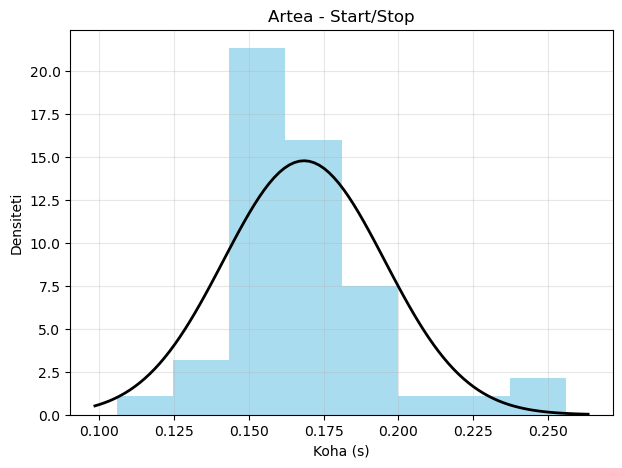

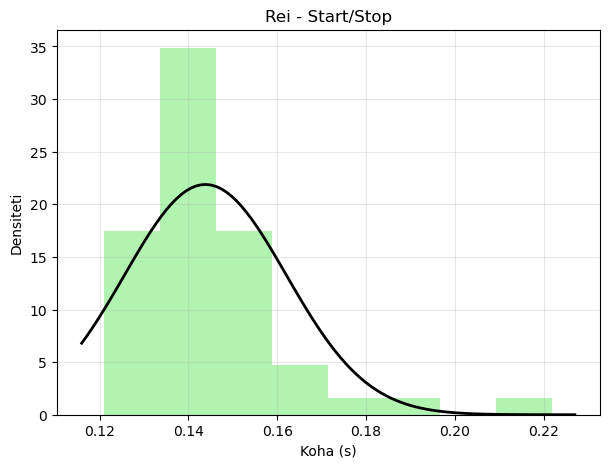

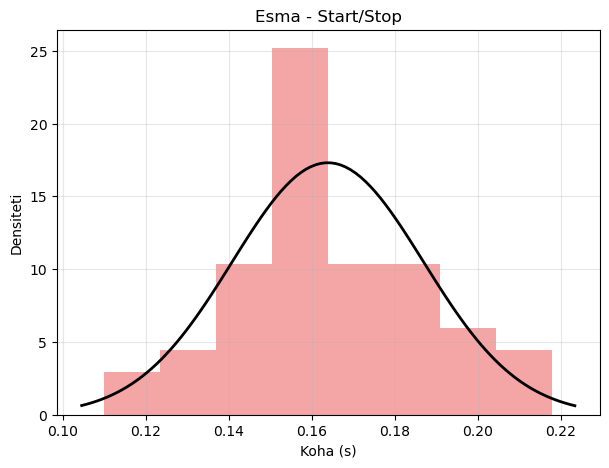

In [25]:
histogram(artea_startstop_s, "Artea - Start/Stop", "skyblue")
histogram(rei_startstop_s, "Rei - Start/Stop", "lightgreen")
histogram(esma_startstop_s, "Esma - Start/Stop", "lightcoral")

---
# **Analiza e te Dhenave:**

Nga histogramet vihet re se matjet nuk jane konstante, por ndryshojne rreth nje vlere mesatare.

Shperndarja e rezultateve afrohet me nje shperndarje Gaussiane.

Ne testin start/stop vihet re variacion me i madh per shkak te reagimit njerezor dhe voneses ne shtypjen e kronometrit.

---

# **Rezultati Final:**

## Vizore

Artea=>
$$
t \approx (0.14 \pm 0.04)s
$$

Rei=>
$$
t \approx (0.18 \pm 0.05)s
$$

Esma=>
$$
t \approx (0.19 \pm 0.05)s
$$

---

## Kronometri 5 Sekonda

Artea=>
$$
t \approx (5.09 \pm 0.08)s
$$

Rei=>
$$
t \approx (4.97 \pm 0.08)s
$$

Esma=>
$$
t \approx (4.93 \pm 0.20)s
$$

---

## Testi Start/Stop

Artea=>
$$
t \approx (0.17 \pm 0.03)s
$$

Rei=>
$$
t \approx (0.14 \pm 0.02)s
$$

Esma=>
$$
t \approx (0.16 \pm 0.03)s
$$

---

# **Diskutim:**

Ky laborator tregoi se koha e reagimit nuk eshte nje vlere konstante, por nje madhesi statistikore.

Histogramet treguan se matjet grumbullohen rreth nje vlere mesatare dhe afrohen me nje shperndarje Gaussiane.

Rritja e numrit te matjeve permireson besueshmerine e rezultateve eksperimentale.